## VOL REGIME

In [1]:
import sys
from pathlib import Path

# Repo root: walk up from notebook file (Cursor) and/or kernel cwd
_nb = globals().get("__vsc_ipynb_file__")
ROOT = None
for start in ([Path(_nb)] if _nb else []) + [Path.cwd()]:
    p = start.resolve()
    if p.suffix == ".ipynb":
        p = p.parent
    for candidate in (p, *p.parents):
        if (candidate / "vol_surface.py").is_file():
            ROOT = candidate
            break
    if ROOT is not None:
        break
if ROOT is None:
    raise FileNotFoundError(
        "Open the Signal_Monitor folder in Cursor, then re-run. "
        f"Could not find vol_surface.py from notebook={_nb!r} cwd={Path.cwd()!r}"
    )
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from volatility_regime import HMMVolatilityRegime

spx_model = HMMVolatilityRegime.from_market("SPX", signal_mode=True)
# nsq_model = HMMVolatilityRegime.from_market("NSDQ", signal_mode=True)
# dji_model = HMMVolatilityRegime.from_market("DJI", signal_mode=True)

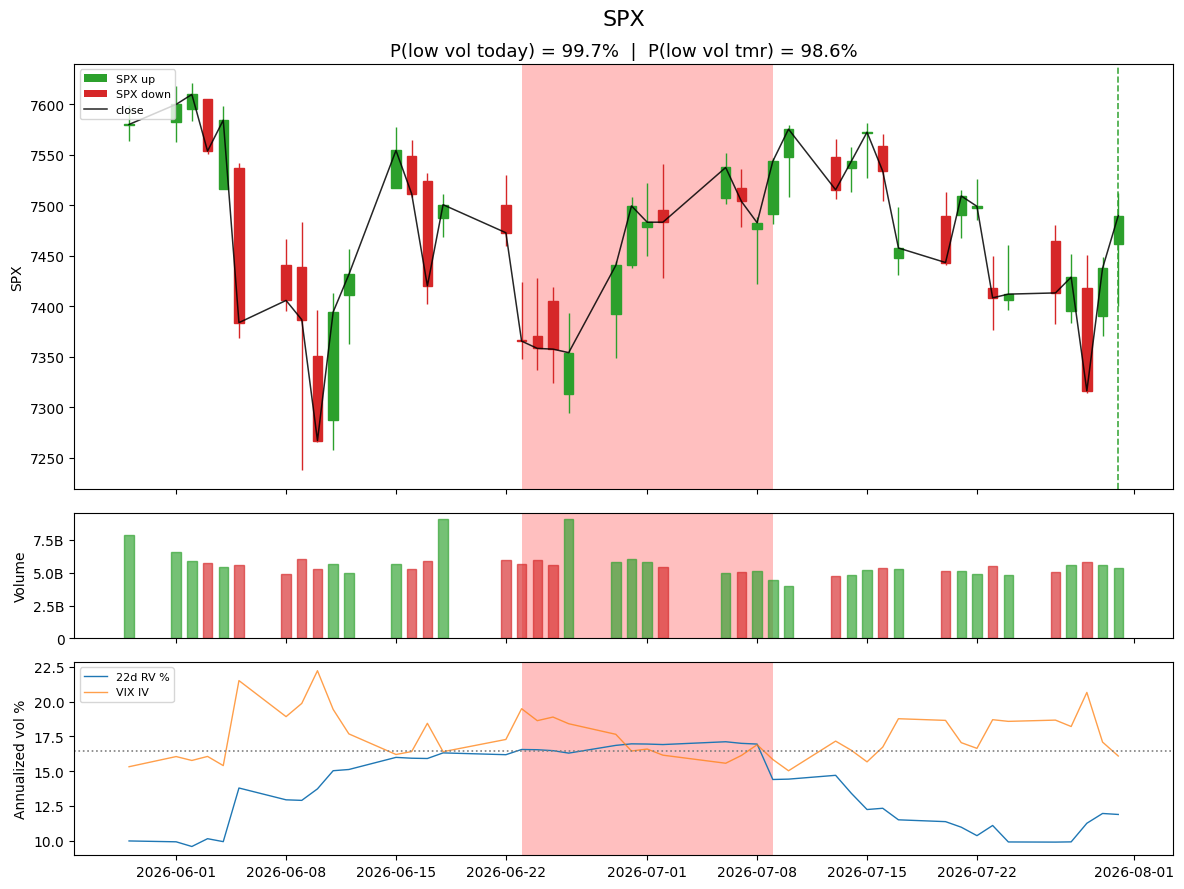


SPX implied vs realized move (1σ)
Spot = 7,490 | IV = 16.1% | 1d hist: avg |move| last 22d
Horizon | Implied   | Historical | Spot ± implied
--------+-----------+------------+---------------
1d      | 76(1.0%)  | 43(0.6%)   | 7,414 | 7,565 
15d     | 294(3.9%) | 245(3.3%)  | 7,196 | 7,784 
22d     | 356(4.8%) | 263(3.5%)  | 7,133 | 7,846 
30d     | 416(5.6%) | 315(4.2%)  | 7,074 | 7,905 


In [2]:
spx_model.display(display_period=44)
# nsq_model.display(display_period=44)
# dji_model.display(display_period=44)